<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
!pip install ucimlrepo

## Машины опорных векторов (SVM)
Метод опорных векторов — алгоритм классификации, основанный на поиске разделяющей гиперплоскости с максимальным
зазором (margin) между классами. Для нелинейно разделимых данных применяется
"kernel trick", позволяющий перевести признаки в пространство более высокой
размерности.

### Используемые библиотеки

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_curve, auc)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

### Датасет

In [128]:
try:
    from ucimlrepo import fetch_ucirepo
    dry_bean = fetch_ucirepo(id=602)
    X = dry_bean.data.features
    y = dry_bean.data.targets
    df = pd.concat([X, y], axis=1)
except:
    url = "https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip"
    import zipfile, io, requests
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    df = pd.read_excel(z.open('Dry_Bean_Dataset.xlsx'))

print(f"Размер датасета: {df.shape}")
print(f"Количество признаков: {df.shape[1] - 1}")
print(f"Количество классов: {df['Class'].nunique()}")

print("\nПример данных:")
print(df.head())

Размер датасета: (13611, 17)
Количество признаков: 16
Количество классов: 7

Пример данных:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRatio  \
0  28395    610.291       208.178117       173.888747     1.197191   
1  28734    638.018       200.524796       182.734419     1.097356   
2  29380    624.110       212.826130       175.931143     1.209713   
3  30008    645.884       210.557999       182.516516     1.153638   
4  30140    620.134       201.847882       190.279279     1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  Roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFac

### Предварительная обработка датасета

In [129]:
X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (9527, 16)
Размер тестовой выборки: (4084, 16)


### Тепловая карта

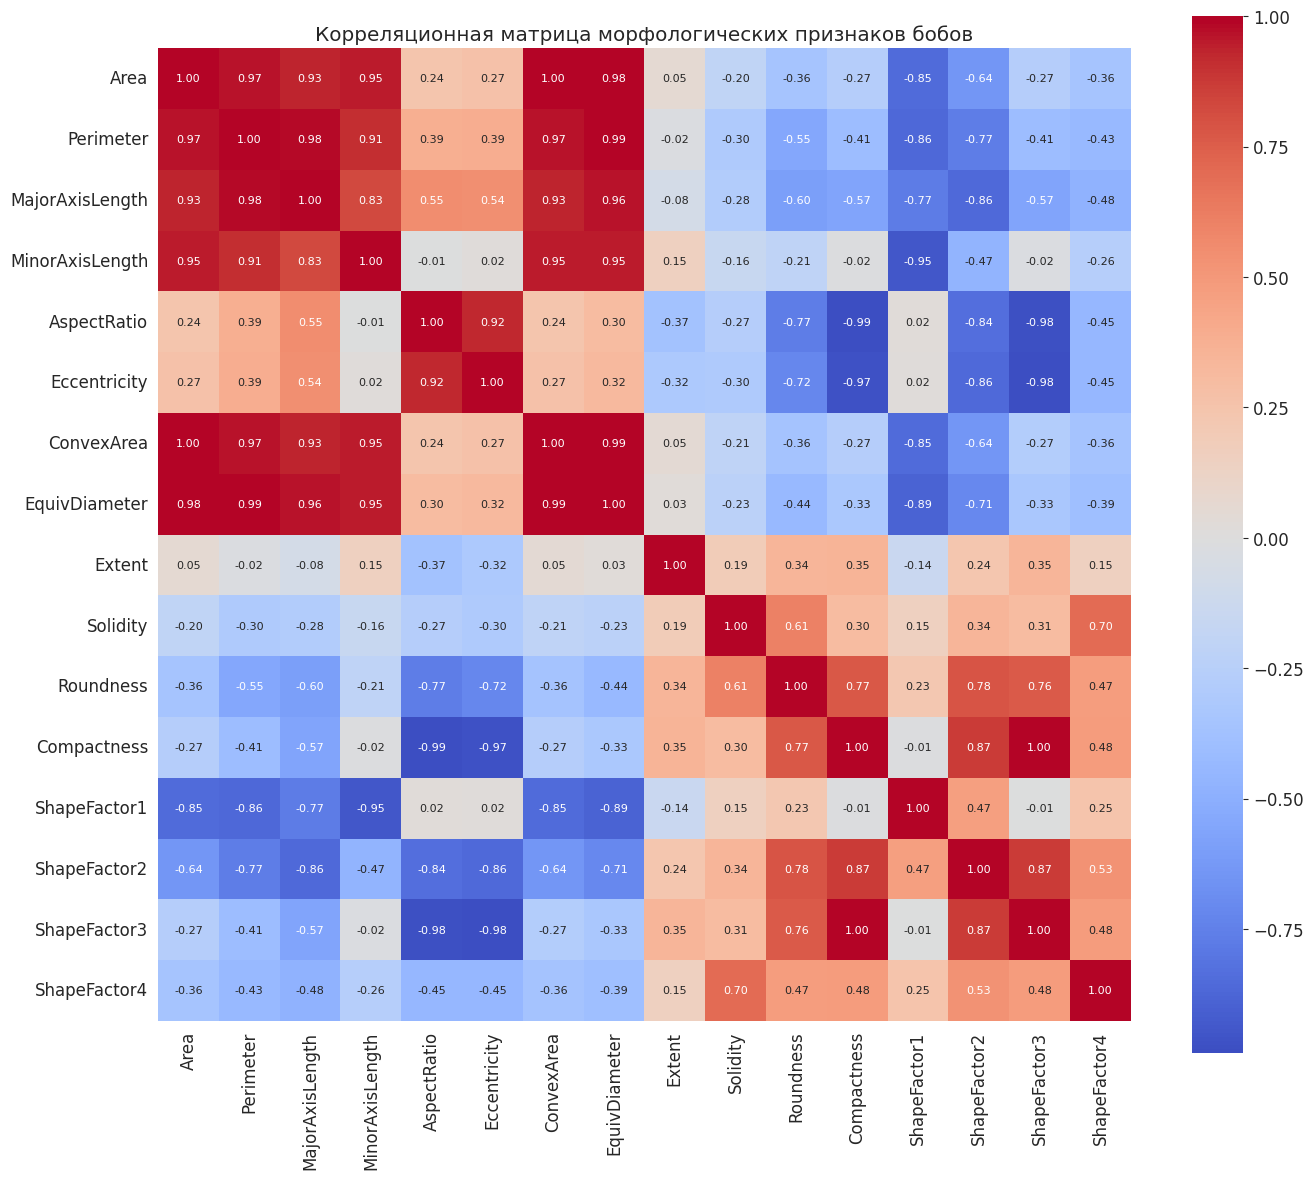

In [130]:
plt.figure(figsize=(14,12))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', square=True, center=0,
            annot_kws={'size': 8})
plt.title('Корреляционная матрица морфологических признаков бобов')
plt.tight_layout()
plt.show()

### Обучение модели

In [131]:
svm = SVC(C=10, gamma=0.1, kernel='rbf')
svm.fit(X_train, y_train)


SVC(C=10, gamma=0.1)

### Прогнозы модели

In [132]:
y_pred = svm.predict(X_test)
y_pred_decision = svm.decision_function(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Точность (Accuracy): {accuracy:.4f}")


🎯 Точность (Accuracy): 0.9283


### Графики выходных результатов

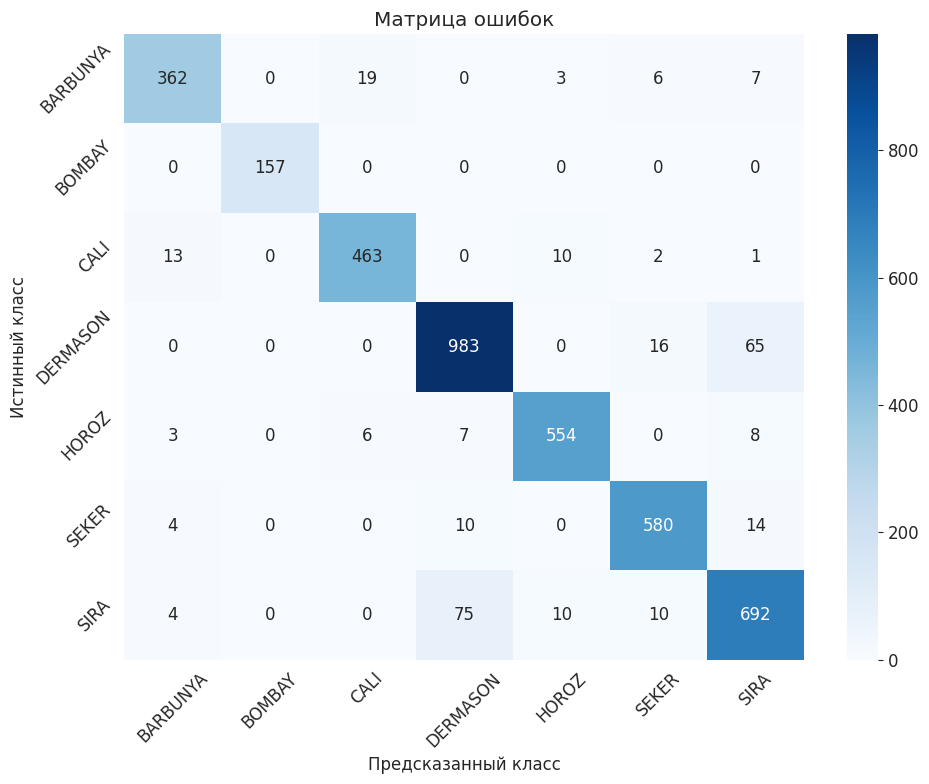

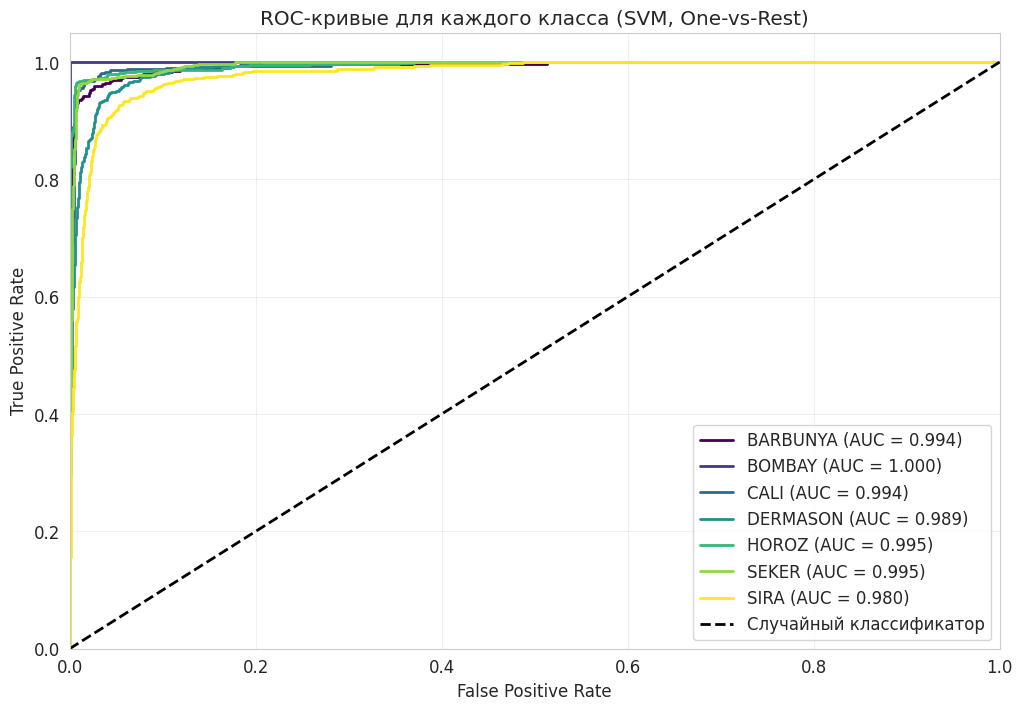

In [133]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm.classes_,
            yticklabels=svm.classes_)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ROC-кривые для многоклассовой классификации (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=svm.classes_)
n_classes = len(svm.classes_)

plt.figure(figsize=(12,8))
colors = plt.cm.viridis(np.linspace(0, 1, n_classes))

for i, (class_name, color) in enumerate(zip(svm.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_decision[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для каждого класса (SVM, One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()